# CholBindNet pocket complexity analysis with dpocket

This notebook:

1. Scans a directory of holo PDB files containing experimentally validated cholesterol.
2. Builds a `dpocket` input file automatically.
3. Runs `dpocket` on those PDBs.
4. Parses the `explicitp` output to extract pocket descriptors such as **volume**.
5. Computes a custom **residue density** metric:

\[
\text{residue density} = \frac{\text{number of unique protein residues within cutoff of cholesterol}}{\text{pocket volume}}
\]

6. Saves summary tables and creates figures that can be used in the CholBindNet revision.

The notebook is written to be flexible because `dpocket` output column names can vary slightly by version.

## What to use for the revision

For the main revision, run this on the **experimentally validated cholesterol-bound pockets**.

That is the cleanest dataset for supporting claims about the complexity of real cholesterol binding sites.

You can optionally run the same workflow on Vina or decoy pockets later as a supplementary comparison, but the main analysis should be based on experimentally validated sites.

In [1]:

# --- Imports ---
import os
import re
import csv
import math
import shlex
import json
import glob
import shutil
import subprocess
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

In [2]:

# --- User configuration ---

# Directory containing holo PDB files with experimentally validated cholesterol bound
PDB_DIR = Path("/home/alexhernandez/CholBindNet/3DCNN/CLR-PDB")

# Output directory for all dpocket outputs, plots, and CSV files
OUT_DIR = Path("./dpocket_cholbindnet_analysis")

# Name/path of the dpocket executable
# Examples:
#   "dpocket"
#   "/usr/local/bin/dpocket"
#   "/path/to/fpocket/bin/dpocket"
DPOCKET_EXE = "/usr/local/bin/dpocket"

# Ligand residue names to treat as cholesterol
# Keep CLR first if that is your standard naming
CHOLESTEROL_RESNAMES = ["CLR", "CHL1", "CHL", "STE", "CHO"]

# Distance cutoff in Angstroms for defining contacting protein residues
# 4.0 A is a reasonable starting point and aligns well with explicit pocket style analyses
CONTACT_CUTOFF = 4.0

# Figure DPI
FIG_DPI = 300

OUT_DIR.mkdir(parents=True, exist_ok=True)

print("PDB_DIR:", PDB_DIR)
print("OUT_DIR:", OUT_DIR.resolve())

PDB_DIR: /home/alexhernandez/CholBindNet/3DCNN/CLR-PDB
OUT_DIR: /home/alexhernandez/CholBindNet/FPocketGNN/dpocket_cholbindnet_analysis


In [3]:

# --- Helper: verify dpocket exists ---

def check_executable(exe_name: str):
    resolved = shutil.which(exe_name) if os.path.sep not in exe_name else exe_name
    if resolved and Path(resolved).exists():
        print(f"Found dpocket: {resolved}")
        return resolved
    raise FileNotFoundError(
        f"Could not find dpocket executable '{exe_name}'. "
        "Edit DPOCKET_EXE at the top of the notebook."
    )

dpocket_path = check_executable(DPOCKET_EXE)

Found dpocket: /usr/local/bin/dpocket


In [4]:

# --- Minimal PDB parser utilities ---

def parse_pdb_atoms(pdb_path: Path):
    '''
    Parse ATOM/HETATM records from a PDB file into a DataFrame.

    Returned columns:
      record_name, atom_name, altloc, resname, chain, resseq, icode,
      x, y, z, element
    '''
    rows = []
    with open(pdb_path, "r", encoding="utf-8", errors="ignore") as fh:
        for line in fh:
            if not (line.startswith("ATOM") or line.startswith("HETATM")):
                continue

            record_name = line[0:6].strip()
            atom_name    = line[12:16].strip()
            altloc       = line[16:17].strip()
            resname      = line[17:20].strip()
            chain        = line[21:22].strip()
            resseq       = line[22:26].strip()
            icode        = line[26:27].strip()
            x            = line[30:38].strip()
            y            = line[38:46].strip()
            z            = line[46:54].strip()
            element      = line[76:78].strip()

            # Keep blank or A altlocs only
            if altloc not in ("", "A"):
                continue

            try:
                x = float(x)
                y = float(y)
                z = float(z)
            except ValueError:
                continue

            rows.append({
                "record_name": record_name,
                "atom_name": atom_name,
                "resname": resname,
                "chain": chain,
                "resseq": resseq,
                "icode": icode,
                "x": x,
                "y": y,
                "z": z,
                "element": element
            })

    return pd.DataFrame(rows)

def residue_uid(df_row):
    return (df_row["chain"], str(df_row["resseq"]).strip(), df_row["icode"], df_row["resname"])

In [5]:

# --- Identify which PDBs contain cholesterol ---

def find_pdbs_with_cholesterol(pdb_dir: Path, chol_resnames):
    pdb_paths = sorted(list(pdb_dir.glob("*.pdb")))
    found = []

    for pdb_path in pdb_paths:
        atoms = parse_pdb_atoms(pdb_path)
        if atoms.empty:
            continue

        het = atoms[atoms["record_name"] == "HETATM"].copy()
        chol = het[het["resname"].isin(chol_resnames)].copy()

        if len(chol) > 0:
            found.append({
                "pdb_file": pdb_path,
                "n_chol_atoms": len(chol),
                "detected_chol_resnames": sorted(chol["resname"].dropna().unique().tolist())
            })

    return pd.DataFrame(found)

pdb_inventory = find_pdbs_with_cholesterol(PDB_DIR, CHOLESTEROL_RESNAMES)
print("PDB files with cholesterol found:", len(pdb_inventory))
display(pdb_inventory.head())

PDB files with cholesterol found: 770


,pdb_file,n_chol_atoms,detected_chol_resnames
0,/home/alexhernandez/CholBindNet/3DCNN/CLR-PDB/...,28,[CLR]
1,/home/alexhernandez/CholBindNet/3DCNN/CLR-PDB/...,28,[CLR]
2,/home/alexhernandez/CholBindNet/3DCNN/CLR-PDB/...,28,[CLR]
3,/home/alexhernandez/CholBindNet/3DCNN/CLR-PDB/...,84,[CLR]
4,/home/alexhernandez/CholBindNet/3DCNN/CLR-PDB/...,28,[CLR]


In [6]:

# --- Build dpocket input file ---
# Format expected by dpocket: <pdb_path> <tab> <ligand_resname>

dpocket_input_path = OUT_DIR / "dpocket_input.txt"

with open(dpocket_input_path, "w", encoding="utf-8") as fh:
    for _, row in pdb_inventory.iterrows():
        # Use the first detected cholesterol resname for that PDB
        ligand_resname = row["detected_chol_resnames"][0]
        fh.write(f"{row['pdb_file']}\t{ligand_resname}\n")

print("Wrote:", dpocket_input_path)
with open(dpocket_input_path, "r", encoding="utf-8") as fh:
    for i, line in enumerate(fh):
        print(line.rstrip())
        if i >= 4:
            break

Wrote: dpocket_cholbindnet_analysis/dpocket_input.txt
/home/alexhernandez/CholBindNet/3DCNN/CLR-PDB/1LRI_protein.pdb	CLR
/home/alexhernandez/CholBindNet/3DCNN/CLR-PDB/1N83_protein.pdb	CLR
/home/alexhernandez/CholBindNet/3DCNN/CLR-PDB/1ZHY_protein.pdb	CLR
/home/alexhernandez/CholBindNet/3DCNN/CLR-PDB/2RH1_protein.pdb	CLR
/home/alexhernandez/CholBindNet/3DCNN/CLR-PDB/2ZXE_protein.pdb	CLR


In [7]:

# --- Run dpocket ---
# This creates files like:
#   <prefix>_explicitp.txt
#   <prefix>_fpocketp.txt
#   <prefix>_fpocketnp.txt

dpocket_prefix = str(OUT_DIR / "chol")

cmd = [dpocket_path, "-f", str(dpocket_input_path), "-o", dpocket_prefix]
print("Running:", " ".join(shlex.quote(x) for x in cmd))

result = subprocess.run(cmd, capture_output=True, text=True)

print("Return code:", result.returncode)
print("\n--- STDOUT ---\n")
print(result.stdout[:5000] if result.stdout else "(no stdout)")
print("\n--- STDERR ---\n")
print(result.stderr[:5000] if result.stderr else "(no stderr)")

if result.returncode != 0:
    raise RuntimeError("dpocket failed. Check the output above.")

Running: /usr/local/bin/dpocket -f dpocket_cholbindnet_analysis/dpocket_input.txt -o dpocket_cholbindnet_analysis/chol
Return code: 0

--- STDOUT ---

<dpocket>s 1/770 - /home/alexhernandez/CholBindNet/3DCNN/CLR-PDB/1LRI_protein.pdb:Having 1547 objects in memory
sorting atoms and vertices or something like this 
sort finished
Having 1636 objects in memory

<dpocket>s 2/770 - /home/alexhernandez/CholBindNet/3DCNN/CLR-PDB/1N83_protein.pdb:Having 1636 objects in memory
sorting atoms and vertices or something like this 
sort finished
Having 1839 objects in memory

<dpocket>s 3/770 - /home/alexhernandez/CholBindNet/3DCNN/CLR-PDB/1ZHY_protein.pdb:Having 1839 objects in memory
sorting atoms and vertices or something like this 
sort finished
Having 2126 objects in memory

<dpocket>s 4/770 - /home/alexhernandez/CholBindNet/3DCNN/CLR-PDB/2RH1_protein.pdb:Having 2126 objects in memory
sorting atoms and vertices or something like this 
sort finished
Having 2465 objects in memory

<dpocket>s 5/770 

In [32]:

# --- Locate dpocket outputs ---

explicitp_path = OUT_DIR / "chol_exp.txt"
fpocketp_path  = OUT_DIR / "chol_fp.txt"
fpocketnp_path = OUT_DIR / "chol_fpn.txt"

for p in [explicitp_path, fpocketp_path, fpocketnp_path]:
    print(p.name, "exists:", p.exists())

chol_exp.txt exists: True
chol_fp.txt exists: True
chol_fpn.txt exists: True


In [33]:

# --- Robust parser for dpocket tables ---

def load_dpocket_table(path: Path):
    '''
    Tries multiple strategies because fpocket/dpocket text tables can vary a bit by version.
    '''
    if not path.exists():
        raise FileNotFoundError(path)

    # First try tab-separated
    try:
        df = pd.read_csv(path, sep="\t", comment="#")
        if df.shape[1] > 1:
            df.columns = [str(c).strip() for c in df.columns]
            return df
    except Exception:
        pass

    # Then try whitespace-separated
    try:
        df = pd.read_csv(path, delim_whitespace=True, comment="#")
        if df.shape[1] > 1:
            df.columns = [str(c).strip() for c in df.columns]
            return df
    except Exception:
        pass

    # Fallback manual parsing
    with open(path, "r", encoding="utf-8", errors="ignore") as fh:
        lines = [ln.strip() for ln in fh if ln.strip() and not ln.startswith("#")]

    header = re.split(r"\s+", lines[0])
    data = [re.split(r"\s+", ln) for ln in lines[1:]]
    df = pd.DataFrame(data, columns=header[:len(data[0])])
    df.columns = [str(c).strip() for c in df.columns]
    return df

explicit_df_raw = load_dpocket_table(explicitp_path)
print("Shape:", explicit_df_raw.shape)
print("Columns:")
print(list(explicit_df_raw.columns))
display(explicit_df_raw.head())

Shape: (770, 57)
Columns:
['pdb', 'lig', 'overlap', 'PP-crit', 'PP-dst', 'crit4', 'crit5', 'crit6', 'crit6_continue', 'lig_vol', 'pock_vol', 'nb_AS', 'nb_AS_norm', 'mean_as_ray', 'mean_as_solv_acc', 'apol_as_prop', 'apol_as_prop_norm', 'mean_loc_hyd_dens', 'mean_loc_hyd_dens_norm', 'hydrophobicity_score', 'volume_score', 'polarity_score', 'polarity_score_norm', 'charge_score', 'flex', 'prop_polar_atm', 'as_density', 'as_density_norm', 'as_max_dst', 'as_max_dst_norm', 'drug_score', 'convex_hull_volume', 'surf_pol_vdw14', 'surf_pol_vdw22', 'surf_apol_vdw14', 'surf_apol_vdw22', 'n_abpa', 'ALA', 'ARG', 'ASN', 'ASP', 'CYS', 'GLN', 'GLU', 'GLY', 'HIS', 'ILE', 'LEU', 'LYS', 'MET', 'PHE', 'PRO', 'SER', 'THR', 'TRP', 'TYR', 'VAL']


,pdb,lig,overlap,PP-crit,PP-dst,crit4,crit5,crit6,crit6_continue,lig_vol,pock_vol,nb_AS,nb_AS_norm,mean_as_ray,mean_as_solv_acc,apol_as_prop,apol_as_prop_norm,mean_loc_hyd_dens,mean_loc_hyd_dens_norm,hydrophobicity_score,volume_score,polarity_score,polarity_score_norm,charge_score,flex,prop_polar_atm,as_density,as_density_norm,as_max_dst,as_max_dst_norm,drug_score,convex_hull_volume,surf_pol_vdw14,surf_pol_vdw22,surf_apol_vdw14,surf_apol_vdw22,n_abpa,ALA,ARG,ASN,ASP,CYS,GLN,GLU,GLY,HIS,ILE,LEU,LYS,MET,PHE,PRO,SER,THR,TRP,TYR,VAL
0,/home/alexhernandez/CholBindNet/3DCNN/CLR-PDB/...,CLR,100.00,1,0.00,1.00,1.00,1,2.00,274.68,935.59,49,0.00,4.16,0.57,0.94,0.00,27.65,0.00,63.63,4.81,6,0.00,1,19.24,16.67,8.08,0.00,23.07,0.00,0.00,230.13,3.21,0.00,54.34,19.11,3,1,0,0,0,0,0,0,1,0,2,7,1,3,2,2,0,1,0,4,3
1,/home/alexhernandez/CholBindNet/3DCNN/CLR-PDB/...,CLR,100.00,1,0.00,1.00,1.00,1,2.00,345.26,1096.50,77,0.00,4.08,0.54,0.73,0.00,29.68,0.00,51.59,4.97,13,0.00,3,19.75,22.99,8.49,0.00,20.26,0.00,0.00,463.89,32.34,10.46,47.18,5.73,8,3,2,0,1,3,1,1,0,1,2,2,2,1,5,0,0,0,1,4,3
2,/home/alexhernandez/CholBindNet/3DCNN/CLR-PDB/...,CLR,100.00,1,0.00,1.00,1.00,1,2.00,324.03,1083.51,72,0.00,3.99,0.49,0.72,0.00,32.62,0.00,47.16,4.84,12,0.00,2,21.19,25.30,8.32,0.00,20.72,0.00,0.00,398.22,23.59,1.74,66.42,9.56,10,1,1,1,0,0,2,1,0,0,4,5,2,0,4,3,1,1,2,1,2
3,/home/alexhernandez/CholBindNet/3DCNN/CLR-PDB/...,CLR,100.00,1,0.00,1.00,1.00,1,2.00,1069.60,1501.45,56,0.00,3.97,0.64,0.80,0.00,12.89,0.00,54.79,4.39,11,0.00,1,75.35,26.04,12.95,0.00,26.67,0.00,0.00,1544.29,58.46,33.29,61.59,21.02,8,2,1,0,0,2,1,1,1,0,4,7,1,0,1,1,2,2,2,1,4
4,/home/alexhernandez/CholBindNet/3DCNN/CLR-PDB/...,CLR,100.00,1,0.00,1.00,1.00,1,2.00,336.99,919.83,37,0.00,4.10,0.65,0.76,0.00,13.57,0.00,53.55,4.90,10,0.00,-1,57.19,28.57,8.83,0.00,21.10,0.00,0.00,275.15,21.52,0.00,122.13,26.76,5,0,1,0,0,0,0,2,1,0,4,2,0,1,1,0,1,2,1,3,1


In [34]:
# --- Normalize likely numeric columns ---

explicit_df = explicit_df_raw.copy()

# Keep identifier/text columns as strings
text_cols = {"pdb", "lig"}

for col in explicit_df.columns:
    if col in text_cols:
        explicit_df[col] = explicit_df[col].astype("string")
    else:
        explicit_df[col] = pd.to_numeric(explicit_df[col], errors="coerce")

display(explicit_df.head())
print(explicit_df[["pdb", "lig"]].head())
print(explicit_df[["pdb", "lig"]].dtypes)

,pdb,lig,overlap,PP-crit,PP-dst,crit4,crit5,crit6,crit6_continue,lig_vol,pock_vol,nb_AS,nb_AS_norm,mean_as_ray,mean_as_solv_acc,apol_as_prop,apol_as_prop_norm,mean_loc_hyd_dens,mean_loc_hyd_dens_norm,hydrophobicity_score,volume_score,polarity_score,polarity_score_norm,charge_score,flex,prop_polar_atm,as_density,as_density_norm,as_max_dst,as_max_dst_norm,drug_score,convex_hull_volume,surf_pol_vdw14,surf_pol_vdw22,surf_apol_vdw14,surf_apol_vdw22,n_abpa,ALA,ARG,ASN,ASP,CYS,GLN,GLU,GLY,HIS,ILE,LEU,LYS,MET,PHE,PRO,SER,THR,TRP,TYR,VAL
0,/home/alexhernandez/CholBindNet/3DCNN/CLR-PDB/...,CLR,100.0,1,0.0,1.0,1.0,1,2.0,274.68,935.59,49,0.0,4.16,0.57,0.94,0.0,27.65,0.0,63.63,4.81,6,0.0,1,19.24,16.67,8.08,0.0,23.07,0.0,0.0,230.13,3.21,0.00,54.34,19.11,3,1,0,0,0,0,0,0,1,0,2,7,1,3,2,2,0,1,0,4,3
1,/home/alexhernandez/CholBindNet/3DCNN/CLR-PDB/...,CLR,100.0,1,0.0,1.0,1.0,1,2.0,345.26,1096.50,77,0.0,4.08,0.54,0.73,0.0,29.68,0.0,51.59,4.97,13,0.0,3,19.75,22.99,8.49,0.0,20.26,0.0,0.0,463.89,32.34,10.46,47.18,5.73,8,3,2,0,1,3,1,1,0,1,2,2,2,1,5,0,0,0,1,4,3
2,/home/alexhernandez/CholBindNet/3DCNN/CLR-PDB/...,CLR,100.0,1,0.0,1.0,1.0,1,2.0,324.03,1083.51,72,0.0,3.99,0.49,0.72,0.0,32.62,0.0,47.16,4.84,12,0.0,2,21.19,25.30,8.32,0.0,20.72,0.0,0.0,398.22,23.59,1.74,66.42,9.56,10,1,1,1,0,0,2,1,0,0,4,5,2,0,4,3,1,1,2,1,2
3,/home/alexhernandez/CholBindNet/3DCNN/CLR-PDB/...,CLR,100.0,1,0.0,1.0,1.0,1,2.0,1069.60,1501.45,56,0.0,3.97,0.64,0.80,0.0,12.89,0.0,54.79,4.39,11,0.0,1,75.35,26.04,12.95,0.0,26.67,0.0,0.0,1544.29,58.46,33.29,61.59,21.02,8,2,1,0,0,2,1,1,1,0,4,7,1,0,1,1,2,2,2,1,4
4,/home/alexhernandez/CholBindNet/3DCNN/CLR-PDB/...,CLR,100.0,1,0.0,1.0,1.0,1,2.0,336.99,919.83,37,0.0,4.10,0.65,0.76,0.0,13.57,0.0,53.55,4.90,10,0.0,-1,57.19,28.57,8.83,0.0,21.10,0.0,0.0,275.15,21.52,0.00,122.13,26.76,5,0,1,0,0,0,0,2,1,0,4,2,0,1,1,0,1,2,1,3,1


                                                 pdb  lig
0  /home/alexhernandez/CholBindNet/3DCNN/CLR-PDB/...  CLR
1  /home/alexhernandez/CholBindNet/3DCNN/CLR-PDB/...  CLR
2  /home/alexhernandez/CholBindNet/3DCNN/CLR-PDB/...  CLR
3  /home/alexhernandez/CholBindNet/3DCNN/CLR-PDB/...  CLR
4  /home/alexhernandez/CholBindNet/3DCNN/CLR-PDB/...  CLR
pdb    string
lig    string
dtype: object


In [35]:

# --- Column name helpers ---
# dpocket column names differ across versions, so we search by multiple patterns.

def find_column(df, candidate_names=None, regex_patterns=None):
    cols = list(df.columns)
    lower_map = {c.lower(): c for c in cols}

    if candidate_names:
        for cand in candidate_names:
            if cand.lower() in lower_map:
                return lower_map[cand.lower()]

    if regex_patterns:
        for pat in regex_patterns:
            for c in cols:
                if re.search(pat, c, flags=re.I):
                    return c

    return None

volume_col = find_column(
    explicit_df,
    candidate_names=["volume", "pock_vol", "pocket_volume"],
    regex_patterns=[r"\bvol", r"volume"]
)

as_density_col = find_column(
    explicit_df,
    candidate_names=["as_density", "density"],
    regex_patterns=[r"as_?density", r"alpha.*density", r"\bdensity\b"]
)

alpha_spheres_col = find_column(
    explicit_df,
    candidate_names=["nb_asph", "n_asph", "number_of_alpha_spheres"],
    regex_patterns=[r"nb_?asph", r"alpha.*sphere", r"n.*asph"]
)

name_col = find_column(
    explicit_df,
    candidate_names=["name", "pdb", "pdb_file", "protein", "filename"],
    regex_patterns=[r"^name$", r"pdb", r"file", r"protein"]
)

print("Detected columns")
print("name_col        =", name_col)
print("volume_col      =", volume_col)
print("as_density_col  =", as_density_col)
print("alpha_spheres_col =", alpha_spheres_col)

Detected columns
name_col        = pdb
volume_col      = pock_vol
as_density_col  = as_density
alpha_spheres_col = None


In [36]:

# --- If needed, inspect columns manually ---
# If one of the detected columns above is None, look at the exact headers here and set it manually.

list(explicit_df.columns)

['pdb',
 'lig',
 'overlap',
 'PP-crit',
 'PP-dst',
 'crit4',
 'crit5',
 'crit6',
 'crit6_continue',
 'lig_vol',
 'pock_vol',
 'nb_AS',
 'nb_AS_norm',
 'mean_as_ray',
 'mean_as_solv_acc',
 'apol_as_prop',
 'apol_as_prop_norm',
 'mean_loc_hyd_dens',
 'mean_loc_hyd_dens_norm',
 'hydrophobicity_score',
 'volume_score',
 'polarity_score',
 'polarity_score_norm',
 'charge_score',
 'flex',
 'prop_polar_atm',
 'as_density',
 'as_density_norm',
 'as_max_dst',
 'as_max_dst_norm',
 'drug_score',
 'convex_hull_volume',
 'surf_pol_vdw14',
 'surf_pol_vdw22',
 'surf_apol_vdw14',
 'surf_apol_vdw22',
 'n_abpa',
 'ALA',
 'ARG',
 'ASN',
 'ASP',
 'CYS',
 'GLN',
 'GLU',
 'GLY',
 'HIS',
 'ILE',
 'LEU',
 'LYS',
 'MET',
 'PHE',
 'PRO',
 'SER',
 'THR',
 'TRP',
 'TYR',
 'VAL']

In [37]:

# --- Compute custom residue-contact metrics directly from the PDBs ---

def pairwise_min_distances(A, B):
    '''
    A: (n,3), B: (m,3)
    returns minimum distance from each row of A to any row of B
    '''
    if len(A) == 0 or len(B) == 0:
        return np.array([])
    diff = A[:, None, :] - B[None, :, :]
    d2 = np.sum(diff * diff, axis=2)
    return np.sqrt(np.min(d2, axis=1))

def compute_contact_metrics_for_pdb(pdb_path: Path, chol_resnames, cutoff=4.0):
    atoms = parse_pdb_atoms(pdb_path)
    if atoms.empty:
        return None

    protein = atoms[atoms["record_name"] == "ATOM"].copy()
    ligand  = atoms[(atoms["record_name"] == "HETATM") & (atoms["resname"].isin(chol_resnames))].copy()

    if protein.empty or ligand.empty:
        return None

    lig_xyz = ligand[["x", "y", "z"]].to_numpy(dtype=float)
    prot_xyz = protein[["x", "y", "z"]].to_numpy(dtype=float)

    min_d = pairwise_min_distances(prot_xyz, lig_xyz)
    protein = protein.copy()
    protein["min_dist_to_chol"] = min_d

    contacting_atoms = protein[protein["min_dist_to_chol"] <= cutoff].copy()

    unique_residues = {
        residue_uid(row)
        for _, row in contacting_atoms.iterrows()
    }

    return {
        "pdb_file": str(pdb_path),
        "pdb_stem": pdb_path.stem,
        "n_protein_atoms_contacting": int(len(contacting_atoms)),
        "n_unique_pocket_residues": int(len(unique_residues)),
        "contact_cutoff_A": float(cutoff)
    }

contact_rows = []
for pdb_path in pdb_inventory["pdb_file"]:
    out = compute_contact_metrics_for_pdb(Path(pdb_path), CHOLESTEROL_RESNAMES, CONTACT_CUTOFF)
    if out is not None:
        contact_rows.append(out)

contact_df = pd.DataFrame(contact_rows)
print("Computed contact metrics for", len(contact_df), "PDBs")
display(contact_df.head())

Computed contact metrics for 770 PDBs


,pdb_file,pdb_stem,n_protein_atoms_contacting,n_unique_pocket_residues,contact_cutoff_A
0,/home/alexhernandez/CholBindNet/3DCNN/CLR-PDB/...,1LRI_protein,22,14,4.0
1,/home/alexhernandez/CholBindNet/3DCNN/CLR-PDB/...,1N83_protein,28,15,4.0
2,/home/alexhernandez/CholBindNet/3DCNN/CLR-PDB/...,1ZHY_protein,25,15,4.0
3,/home/alexhernandez/CholBindNet/3DCNN/CLR-PDB/...,2RH1_protein,26,17,4.0
4,/home/alexhernandez/CholBindNet/3DCNN/CLR-PDB/...,2ZXE_protein,12,7,4.0


In [38]:
# --- Build a merge key between dpocket output and local file names ---

def stem_from_any_path(x):
    if pd.isna(x):
        return pd.NA
    s = str(x).strip()
    return Path(s).stem

analysis_df = explicit_df.copy()

if name_col is None:
    raise ValueError("name_col is None, but it should be 'pdb' for your dpocket output.")

analysis_df["pdb_stem"] = analysis_df[name_col].astype("string").apply(stem_from_any_path)
contact_df["pdb_stem"] = contact_df["pdb_stem"].astype("string").str.strip()
analysis_df["pdb_stem"] = analysis_df["pdb_stem"].astype("string").str.strip()

print("Example dpocket stems:")
display(analysis_df[[name_col, "pdb_stem"]].head())

print("Example contact stems:")
display(contact_df[["pdb_file", "pdb_stem"]].head())

merged_df = analysis_df.merge(contact_df, on="pdb_stem", how="left")

merged_df["pocket_volume"] = pd.to_numeric(merged_df[volume_col], errors="coerce")
merged_df["residue_density"] = (
    merged_df["n_unique_pocket_residues"] / merged_df["pocket_volume"]
)

if "nb_AS" in merged_df.columns:
    merged_df["n_alpha_spheres"] = pd.to_numeric(merged_df["nb_AS"], errors="coerce")
    merged_df["alpha_sphere_density_per_volume"] = (
        merged_df["n_alpha_spheres"] / merged_df["pocket_volume"]
    )

if as_density_col is not None:
    merged_df["dpocket_as_density"] = pd.to_numeric(merged_df[as_density_col], errors="coerce")

print("Matched rows:", merged_df["n_unique_pocket_residues"].notna().sum(), "of", len(merged_df))
display(merged_df.head())

Example dpocket stems:


,pdb,pdb_stem
0,/home/alexhernandez/CholBindNet/3DCNN/CLR-PDB/...,1LRI_protein
1,/home/alexhernandez/CholBindNet/3DCNN/CLR-PDB/...,1N83_protein
2,/home/alexhernandez/CholBindNet/3DCNN/CLR-PDB/...,1ZHY_protein
3,/home/alexhernandez/CholBindNet/3DCNN/CLR-PDB/...,2RH1_protein
4,/home/alexhernandez/CholBindNet/3DCNN/CLR-PDB/...,2ZXE_protein


Example contact stems:


,pdb_file,pdb_stem
0,/home/alexhernandez/CholBindNet/3DCNN/CLR-PDB/...,1LRI_protein
1,/home/alexhernandez/CholBindNet/3DCNN/CLR-PDB/...,1N83_protein
2,/home/alexhernandez/CholBindNet/3DCNN/CLR-PDB/...,1ZHY_protein
3,/home/alexhernandez/CholBindNet/3DCNN/CLR-PDB/...,2RH1_protein
4,/home/alexhernandez/CholBindNet/3DCNN/CLR-PDB/...,2ZXE_protein


Matched rows: 770 of 770


,pdb,lig,overlap,PP-crit,PP-dst,crit4,crit5,crit6,crit6_continue,lig_vol,pock_vol,nb_AS,nb_AS_norm,mean_as_ray,mean_as_solv_acc,apol_as_prop,apol_as_prop_norm,mean_loc_hyd_dens,mean_loc_hyd_dens_norm,hydrophobicity_score,volume_score,polarity_score,polarity_score_norm,charge_score,flex,prop_polar_atm,as_density,as_density_norm,as_max_dst,as_max_dst_norm,drug_score,convex_hull_volume,surf_pol_vdw14,surf_pol_vdw22,surf_apol_vdw14,surf_apol_vdw22,n_abpa,ALA,ARG,ASN,ASP,CYS,GLN,GLU,GLY,HIS,ILE,LEU,LYS,MET,PHE,PRO,SER,THR,TRP,TYR,VAL,pdb_stem,pdb_file,n_protein_atoms_contacting,n_unique_pocket_residues,contact_cutoff_A,pocket_volume,residue_density,n_alpha_spheres,alpha_sphere_density_per_volume,dpocket_as_density
0,/home/alexhernandez/CholBindNet/3DCNN/CLR-PDB/...,CLR,100.0,1,0.0,1.0,1.0,1,2.0,274.68,935.59,49,0.0,4.16,0.57,0.94,0.0,27.65,0.0,63.63,4.81,6,0.0,1,19.24,16.67,8.08,0.0,23.07,0.0,0.0,230.13,3.21,0.00,54.34,19.11,3,1,0,0,0,0,0,0,1,0,2,7,1,3,2,2,0,1,0,4,3,1LRI_protein,/home/alexhernandez/CholBindNet/3DCNN/CLR-PDB/...,22,14,4.0,935.59,0.014964,49,0.052373,8.08
1,/home/alexhernandez/CholBindNet/3DCNN/CLR-PDB/...,CLR,100.0,1,0.0,1.0,1.0,1,2.0,345.26,1096.50,77,0.0,4.08,0.54,0.73,0.0,29.68,0.0,51.59,4.97,13,0.0,3,19.75,22.99,8.49,0.0,20.26,0.0,0.0,463.89,32.34,10.46,47.18,5.73,8,3,2,0,1,3,1,1,0,1,2,2,2,1,5,0,0,0,1,4,3,1N83_protein,/home/alexhernandez/CholBindNet/3DCNN/CLR-PDB/...,28,15,4.0,1096.50,0.013680,77,0.070223,8.49
2,/home/alexhernandez/CholBindNet/3DCNN/CLR-PDB/...,CLR,100.0,1,0.0,1.0,1.0,1,2.0,324.03,1083.51,72,0.0,3.99,0.49,0.72,0.0,32.62,0.0,47.16,4.84,12,0.0,2,21.19,25.30,8.32,0.0,20.72,0.0,0.0,398.22,23.59,1.74,66.42,9.56,10,1,1,1,0,0,2,1,0,0,4,5,2,0,4,3,1,1,2,1,2,1ZHY_protein,/home/alexhernandez/CholBindNet/3DCNN/CLR-PDB/...,25,15,4.0,1083.51,0.013844,72,0.066451,8.32
3,/home/alexhernandez/CholBindNet/3DCNN/CLR-PDB/...,CLR,100.0,1,0.0,1.0,1.0,1,2.0,1069.60,1501.45,56,0.0,3.97,0.64,0.80,0.0,12.89,0.0,54.79,4.39,11,0.0,1,75.35,26.04,12.95,0.0,26.67,0.0,0.0,1544.29,58.46,33.29,61.59,21.02,8,2,1,0,0,2,1,1,1,0,4,7,1,0,1,1,2,2,2,1,4,2RH1_protein,/home/alexhernandez/CholBindNet/3DCNN/CLR-PDB/...,26,17,4.0,1501.45,0.011322,56,0.037297,12.95
4,/home/alexhernandez/CholBindNet/3DCNN/CLR-PDB/...,CLR,100.0,1,0.0,1.0,1.0,1,2.0,336.99,919.83,37,0.0,4.10,0.65,0.76,0.0,13.57,0.0,53.55,4.90,10,0.0,-1,57.19,28.57,8.83,0.0,21.10,0.0,0.0,275.15,21.52,0.00,122.13,26.76,5,0,1,0,0,0,0,2,1,0,4,2,0,1,1,0,1,2,1,3,1,2ZXE_protein,/home/alexhernandez/CholBindNet/3DCNN/CLR-PDB/...,12,7,4.0,919.83,0.007610,37,0.040225,8.83


In [39]:

# --- Save merged metric table ---

summary_csv = OUT_DIR / "cholesterol_pocket_complexity_metrics.csv"
merged_df.to_csv(summary_csv, index=False)
print("Saved:", summary_csv)

Saved: dpocket_cholbindnet_analysis/cholesterol_pocket_complexity_metrics.csv


In [40]:

# --- Summary statistics for the revision ---

summary_stats = pd.DataFrame({
    "metric": ["pocket_volume", "n_unique_pocket_residues", "residue_density"]
})

def metric_summary(series):
    s = pd.to_numeric(series, errors="coerce").dropna()
    return {
        "n": len(s),
        "mean": s.mean(),
        "median": s.median(),
        "std": s.std(ddof=1) if len(s) > 1 else np.nan,
        "min": s.min(),
        "max": s.max(),
        "q25": s.quantile(0.25),
        "q75": s.quantile(0.75)
    }

rows = []
for metric in ["pocket_volume", "n_unique_pocket_residues", "residue_density"]:
    stats = metric_summary(merged_df[metric])
    stats["metric"] = metric
    rows.append(stats)

summary_stats = pd.DataFrame(rows)[["metric", "n", "mean", "median", "std", "min", "q25", "q75", "max"]]
display(summary_stats)

summary_stats.to_csv(OUT_DIR / "summary_statistics.csv", index=False)

,metric,n,mean,median,std,min,q25,q75,max
0,pocket_volume,770,2373.038688,1636.10000,2177.315582,252.47000,880.030000,3086.305000,18342.630000
1,n_unique_pocket_residues,770,23.779221,17.00000,20.254379,1.00000,9.000000,30.750000,131.000000
2,residue_density,770,0.010688,0.01018,0.003756,0.00173,0.008283,0.012595,0.034075


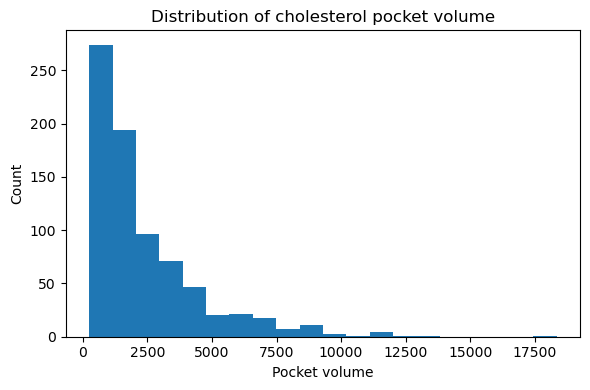

In [41]:

# --- Figure 1: pocket volume distribution ---

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(merged_df["pocket_volume"].dropna(), bins=20)
ax.set_xlabel("Pocket volume")
ax.set_ylabel("Count")
ax.set_title("Distribution of cholesterol pocket volume")
fig.tight_layout()
fig.savefig(OUT_DIR / "figure_pocket_volume_histogram.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()

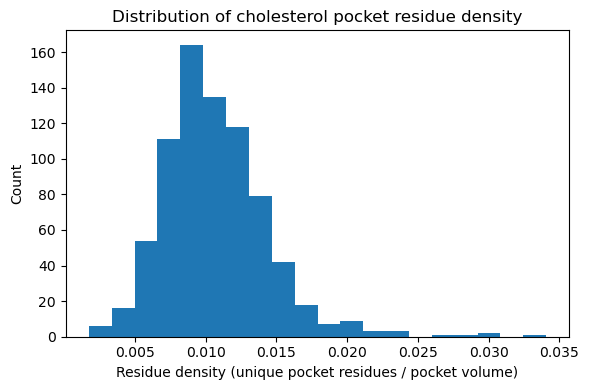

In [42]:

# --- Figure 2: residue density distribution ---

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(merged_df["residue_density"].replace([np.inf, -np.inf], np.nan).dropna(), bins=20)
ax.set_xlabel("Residue density (unique pocket residues / pocket volume)")
ax.set_ylabel("Count")
ax.set_title("Distribution of cholesterol pocket residue density")
fig.tight_layout()
fig.savefig(OUT_DIR / "figure_residue_density_histogram.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()

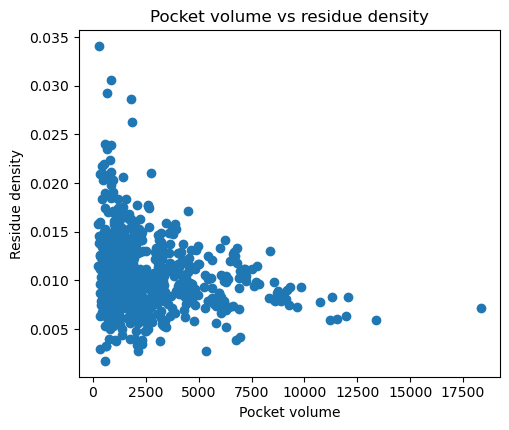

Pearson r = -0.1938


In [43]:

# --- Figure 3: volume vs residue density ---

plot_df = merged_df.replace([np.inf, -np.inf], np.nan).dropna(subset=["pocket_volume", "residue_density"]).copy()

fig, ax = plt.subplots(figsize=(5.2, 4.4))
ax.scatter(plot_df["pocket_volume"], plot_df["residue_density"])
ax.set_xlabel("Pocket volume")
ax.set_ylabel("Residue density")
ax.set_title("Pocket volume vs residue density")
fig.tight_layout()
fig.savefig(OUT_DIR / "figure_volume_vs_residue_density.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()

if len(plot_df) >= 3:
    r = plot_df["pocket_volume"].corr(plot_df["residue_density"], method="pearson")
    print(f"Pearson r = {r:.4f}")

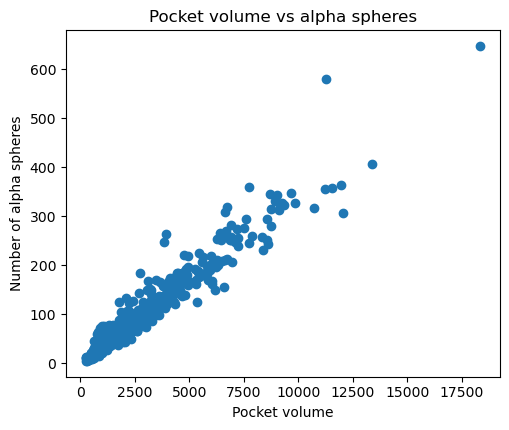

In [44]:

# --- Figure 4: optional alpha-sphere relationships if available ---

if "n_alpha_spheres" in merged_df.columns:
    tmp = merged_df.replace([np.inf, -np.inf], np.nan).dropna(subset=["n_alpha_spheres", "pocket_volume"])
    fig, ax = plt.subplots(figsize=(5.2, 4.4))
    ax.scatter(tmp["pocket_volume"], tmp["n_alpha_spheres"])
    ax.set_xlabel("Pocket volume")
    ax.set_ylabel("Number of alpha spheres")
    ax.set_title("Pocket volume vs alpha spheres")
    fig.tight_layout()
    fig.savefig(OUT_DIR / "figure_volume_vs_alpha_spheres.png", dpi=FIG_DPI, bbox_inches="tight")
    plt.show()
else:
    print("No alpha sphere count column detected in dpocket output.")

## Optional: compare complexity against model outcomes

To directly support the revision, it helps to compare these complexity metrics against model performance.

For example, create a CSV with columns such as:

- `pdb_stem`
- `chol_gnn_correct`
- `chol_gat_correct`
- `chol_gcn_correct`

or a long-format table identifying whether each pocket was correctly classified.

Then merge that table with the complexity metrics and compare:
- Chol-GNN correct vs incorrect
- cases where Chol-GNN succeeds but GAT/GCN fail
- high-complexity vs low-complexity pockets

In [45]:

# --- OPTIONAL: merge with model performance file ---
# Set this path if you already have per-PDB evaluation results.

MODEL_RESULTS_CSV = None
# Example:
# MODEL_RESULTS_CSV = Path("/absolute/path/to/per_pdb_model_results.csv")

if MODEL_RESULTS_CSV is not None:
    perf_df = pd.read_csv(MODEL_RESULTS_CSV)

    # Make sure the performance file has a compatible key
    if "pdb_stem" not in perf_df.columns:
        possible_key = None
        for c in perf_df.columns:
            if re.search(r"pdb|file|name", c, flags=re.I):
                possible_key = c
                break
        if possible_key is None:
            raise ValueError("Could not find a PDB/file column in MODEL_RESULTS_CSV.")
        perf_df["pdb_stem"] = perf_df[possible_key].astype(str).apply(lambda x: Path(x).stem)

    compare_df = merged_df.merge(perf_df, on="pdb_stem", how="inner")
    print("Rows after merging with performance file:", len(compare_df))
    display(compare_df.head())
else:
    print("MODEL_RESULTS_CSV not set. Skipping model-comparison section.")

MODEL_RESULTS_CSV not set. Skipping model-comparison section.


In [46]:

# --- OPTIONAL example plots if MODEL_RESULTS_CSV was provided ---
# This cell assumes a boolean/int column named 'chol_gnn_correct' exists.

if "compare_df" in globals() and "chol_gnn_correct" in compare_df.columns:
    tmp = compare_df.copy()
    tmp["chol_gnn_correct"] = tmp["chol_gnn_correct"].astype(int)

    fig, ax = plt.subplots(figsize=(5.5, 4.2))
    data0 = tmp.loc[tmp["chol_gnn_correct"] == 0, "pocket_volume"].dropna().values
    data1 = tmp.loc[tmp["chol_gnn_correct"] == 1, "pocket_volume"].dropna().values
    ax.boxplot([data0, data1], labels=["Incorrect", "Correct"])
    ax.set_ylabel("Pocket volume")
    ax.set_title("Chol-GNN performance vs pocket volume")
    fig.tight_layout()
    fig.savefig(OUT_DIR / "figure_cholgnn_vs_pocket_volume.png", dpi=FIG_DPI, bbox_inches="tight")
    plt.show()

    fig, ax = plt.subplots(figsize=(5.5, 4.2))
    data0 = tmp.loc[tmp["chol_gnn_correct"] == 0, "residue_density"].replace([np.inf, -np.inf], np.nan).dropna().values
    data1 = tmp.loc[tmp["chol_gnn_correct"] == 1, "residue_density"].replace([np.inf, -np.inf], np.nan).dropna().values
    ax.boxplot([data0, data1], labels=["Incorrect", "Correct"])
    ax.set_ylabel("Residue density")
    ax.set_title("Chol-GNN performance vs residue density")
    fig.tight_layout()
    fig.savefig(OUT_DIR / "figure_cholgnn_vs_residue_density.png", dpi=FIG_DPI, bbox_inches="tight")
    plt.show()
else:
    print("Performance comparison plots skipped.")

Performance comparison plots skipped.


## Notes

- If your `dpocket` output uses slightly different column names, the only part you may need to adjust is the automatic column detection cell.
- If your cholesterol residue name is always `CLR`, you can simplify `CHOLESTEROL_RESNAMES = ["CLR"]`.
- If a structure contains multiple cholesterol molecules, this notebook currently computes protein contacts to **all cholesterol atoms present in that PDB**. If you want per-cholesterol-instance analysis, that can be added as a refinement.

In [47]:

# --- Quick file listing of generated outputs ---

for p in sorted(OUT_DIR.glob("*")):
    print(p.name)

chol_exp.txt
chol_fp.txt
chol_fpn.txt
cholesterol_pocket_complexity_metrics.csv
dpocket_input.txt
figure_pocket_volume_histogram.png
figure_residue_density_histogram.png
figure_volume_vs_alpha_spheres.png
figure_volume_vs_residue_density.png
summary_statistics.csv
